# IDA117V — Scope Notebook, Reorganised by Test Scope Topic
This is **your lecturer's own code** from `IDA117VScope.ipynb`, kept as close to the original as possible, but re-cut and labelled to follow the exact Part 1–10 + Bonus structure of `Test_Scope.pdf`. Use this as your test-day skeleton: open it, and every section title tells you which part of the memo you're answering.

**What changed from the original file:**
- Split into clearly labelled sections matching the scope document (the original ran everything together in sequence).
- Fixed a handful of small bugs/typos that were in the original cells (`fare_outiers` → `fare_outliers`, `Trainig` → `Training`, `{auc:3f}` → `{auc:.3f}`) so it runs cleanly.
- Changed the file path from `/content/titanic.csv` (Colab) to just `titanic.csv` (Jupyter Notebook / Anaconda — the file sits next to your notebook, no internet needed).
- Added a **correlation heatmap**, an explicit **Part 10 written interpretation**, and the **Bonus Decision Tree / Random Forest comparison** — these are required by the scope doc but weren't in the original scope notebook, so they're written in the same plain style as your lecturer's code and clearly marked `# ADDED`.

**Target column:** `Survived` (0 = did not survive, 1 = survived). On test day, swap the CSV and column names for whatever dataset you're given — the section order stays identical.

## Part 0 — Imports
*(from the original notebook, unchanged)*

In [1]:
#Data Manipulation
import pandas as pd
import numpy as np


#Visualisation
import matplotlib.pyplot as plt

In [2]:
#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


#Evaluation
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

In [3]:
#Outlier Detection
from sklearn.ensemble import IsolationForest

#Ignore unnecssary warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("titanic.csv") #csv path -- CHANGE this to whatever file you're given on test day

## Part 1 — Dataset Exploration (10 marks)
*Scope requirements: import libraries ✓ (Part 0) | load dataset ✓ | first 5 rows | last 5 rows | shape | dtypes | describe()*

In [5]:
#Display 1st five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# ADDED -- scope explicitly asks for the LAST 5 rows too
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
#Understand the Dataset
print("Dataset Shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 12)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
#Descriptive Statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Part 2 — Exploratory Data Analysis (EDA)
*Scope requirements: summary statistics ✓ (Part 1 describe()) | class distribution | histogram | box plot | correlation heatmap | bar chart*

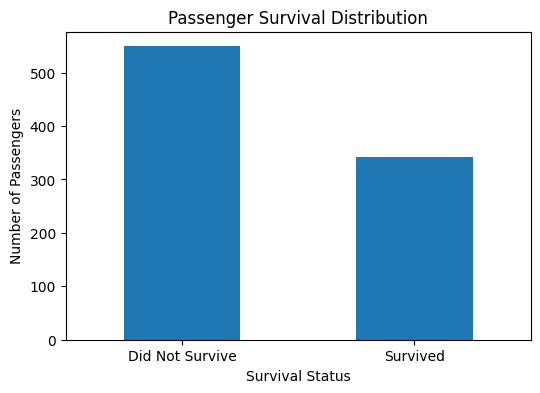

In [9]:
#Exploratory Data Analysis
#Class Distribution
survival_counts = df["Survived"].value_counts()

survival_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Passenger Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0,1], ["Did Not Survive", "Survived"], rotation=0)
plt.show()

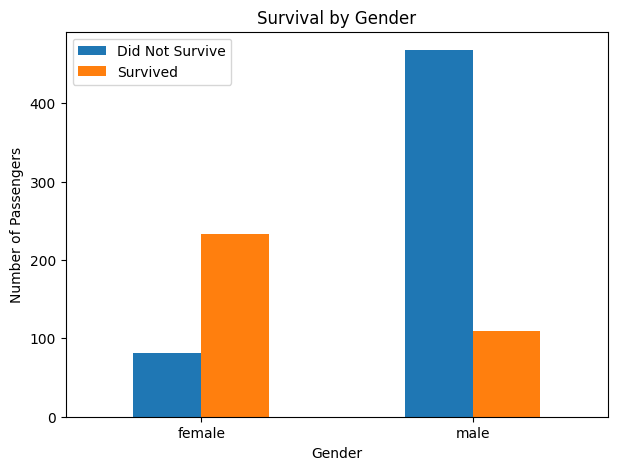

In [10]:
#Survival by Gender  -- this is the lecturer's BAR CHART example (categorical attribute)
gender_survival =pd.crosstab(
    df["Sex"],
    df["Survived"]
)

gender_survival.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.xticks(rotation=0)
plt.show()

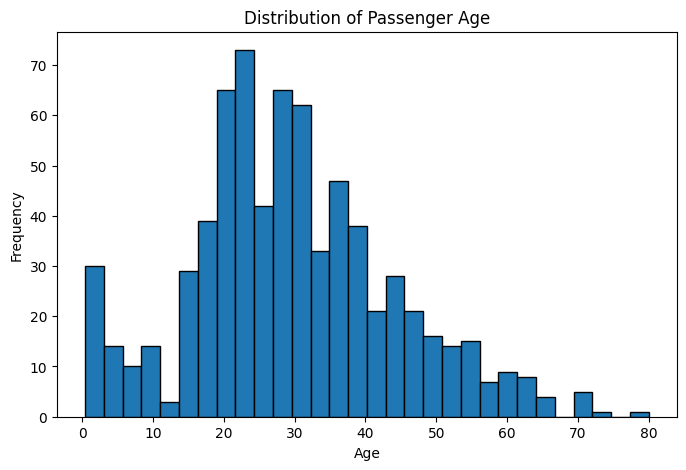

In [11]:
#Age Distribution -- HISTOGRAM
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

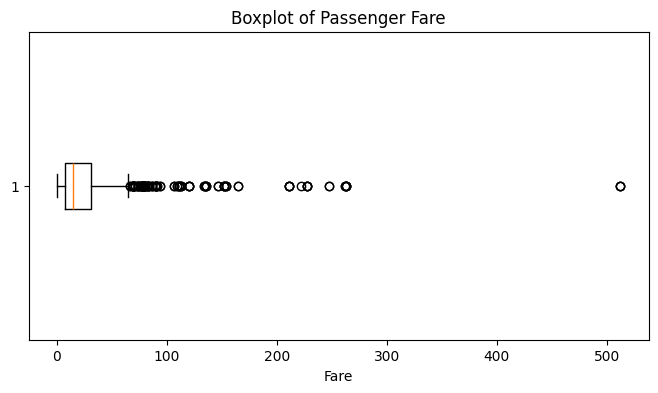

In [12]:
#Detect Outliners Using Boxplot -- BOX PLOT
plt.figure(figsize=(8,4))

plt.boxplot(
    df["Fare"],
    vert=False
)

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")
plt.show()

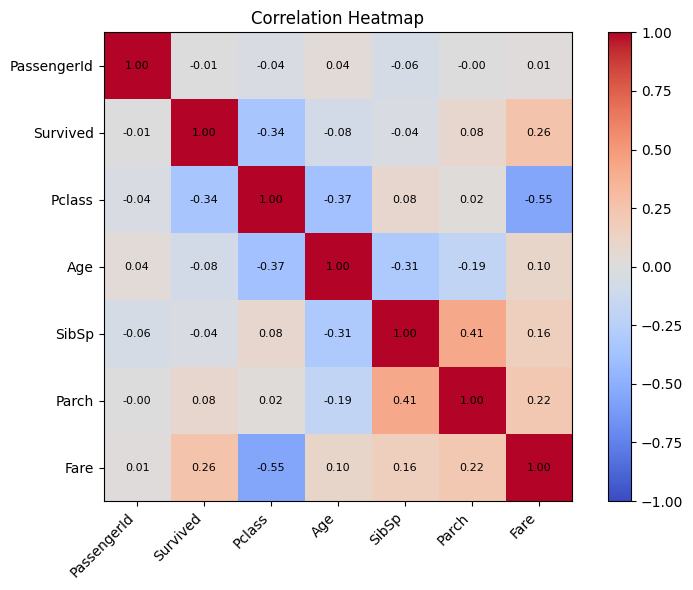

In [13]:
# ADDED -- CORRELATION HEATMAP (required by scope, not in the original scope notebook)
# Uses matplotlib only, in the same plain style as the rest of this notebook (no seaborn needed)
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# write the correlation value inside each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
fig.colorbar(im)
plt.tight_layout()
plt.show()

## Part 3 — Missing Values
*Scope requirements: identify missing values | visualise them | decide + apply a handling strategy*

In [14]:
#Check Missing Values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Age         177
Cabin       687
Embarked      2
dtype: int64


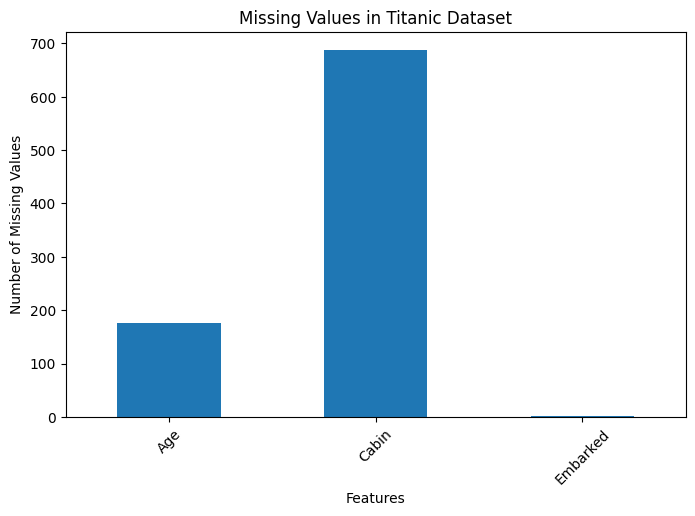

In [15]:
#Visualise Missing Values
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [16]:
#Handle Missing Values
#For Simplicity

#replace missing Age values with median
#replace missing Embarked values with mode
#remove Cabin because it contains many missing values

#Fill missing Age values using median
df["Age"] = df["Age"].fillna(df["Age"].median())

#Fill missing Embarked values using mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#Remove Cabin
df = df.drop(columns=["Cabin"])

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Part 4 — Outlier Detection
*Scope requirements: Method 1 = box plot ✓ (also shown in Part 2 above) | Method 2 = IQR | identify the outliers clearly*

In [17]:
#Detect Outliers Using IQR
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 -  1.5 * IQR
upper_bound = Q3 +  1.5 * IQR

fare_outliers = df[
    (df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)
]

print("Number of Fare outliers:", len(fare_outliers))

fare_outliers[["PassengerId", "Fare"]].head(10)

Number of Fare outliers: 116


,PassengerId,Fare
1,2,71.2833
27,28,263.0000
31,32,146.5208
34,35,82.1708
52,53,76.7292
61,62,80.0000
62,63,83.4750
72,73,73.5000
88,89,263.0000
102,103,77.2875


## Part 5 — Anomaly Detection
*Scope requirements: identify anomalies | visualise them*

In [18]:
#Detect Anomalies Using Isolation Forest
anomaly_data = df[["Age", "Fare"]].copy()

isolation_forest =  IsolationForest(
    contamination=0.05,
    random_state=42
)

df["Anomaly"] = isolation_forest.fit_predict(anomaly_data)

print(df["Anomaly"].value_counts())

Anomaly
 1    846
-1     45
Name: count, dtype: int64


In [19]:
anomalies = df[df["Anomaly"] == -1]

anomalies[
    ["PassengerId", "Age", "Fare", "Survived"]
          ].head(10)

,PassengerId,Age,Fare,Survived
27,28,19.0,263.0000,0
54,55,65.0,61.9792,0
88,89,23.0,263.0000,1
96,97,71.0,34.6542,0
116,117,70.5,7.7500,0
118,119,24.0,247.5208,0
195,196,58.0,146.5208,1
258,259,35.0,512.3292,1
268,269,58.0,153.4625,1
275,276,63.0,77.9583,1


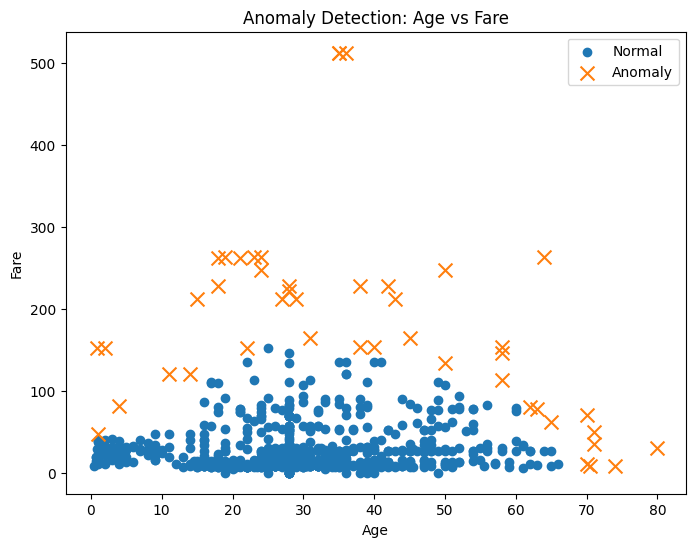

In [20]:
#Visualise the Anomalies
#Outliers and anomalies are related but not necessarily identical concepts
normal = df[df["Anomaly"] == 1]
anomalies = df[df["Anomaly"] == -1]

plt.figure(figsize=(8,6))

plt.scatter(
    normal["Age"],
    normal["Fare"],
    label="Normal"
)

plt.scatter(
    anomalies["Age"],
    anomalies["Fare"],
    marker="x",
    s=100,
    label="Anomaly"
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Anomaly Detection: Age vs Fare")
plt.legend()
plt.show()

## Part 6 — Feature Selection (Data Pre-processing)
*Scope requirements: show numerical vs categorical | encode categorical to numerical | standardise the dataset*

In [21]:
#Select Features for Logistic Regression
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
] #These features we use them to determince the predictions

X = df[features]
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [22]:
# ADDED -- explicitly showing which columns are numerical vs categorical (scope asks for this by name)
print("Numerical features:", X.select_dtypes(include=np.number).columns.tolist())
print("Categorical features:", X.select_dtypes(include="object").columns.tolist())

Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


In [23]:
#Convert Categorical Variables
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X.head() #Note on previous colab a different method was used to convert

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Part 7 — Train/Test Split
*Scope requirements: split into train/test | ratio is SPECIFIED in the question — read carefully, don't assume 80/20*

In [24]:
#Split the Dataset

#Use 80% for training and 20% for testing  -- CHANGE test_size if the question gives a different ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [25]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Feeding data into trainig and testing

## Part 8 — Logistic Regression Model
*Scope requirements: fit the training data | predict on test set | show prediction probabilities | model accuracy*

In [26]:
#Build Logistic Regression Model
model = LogisticRegression(
    max_iter=1000,
    random_state=42

)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
#Make Predictions
y_pred = model.predict(X_test_scaled)

y_probability = model.predict_proba(X_test_scaled)[:,1]

print(y_probability[:10])   # ADDED -- scope asks you to DISPLAY the prediction probabilities

[0.06625616 0.04657124 0.15159972 0.03479639 0.68361793 0.44460255
 0.75604101 0.32607203 0.34350779 0.15906685]


In [28]:
#Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8045


## Part 9 — Model Evaluation (Performance Metrics)
*Scope requirements: classification report | confusion matrix | ROC curve | ROC-AUC score*

In [29]:
#Classification Report
print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

#The report contains four particularly important measures:
#Precision: How many passengers predicted as belonging to a class were correctly classified.
#Recall: How many actual members of that class were correctly detected.
#F1-score: Harmonic balance between precision and recall.
#Support: Number of observations belonging to each class.

Classification Report

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [30]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[98 12]
 [23 46]]


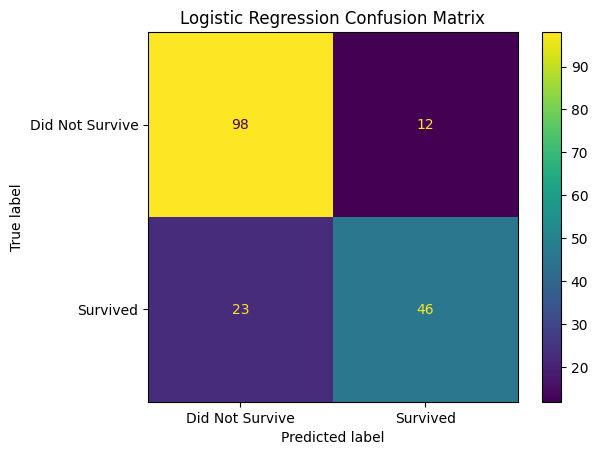

In [31]:
#Visualise the Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=[
        "Did Not Survive",
        "Survived"
    ]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

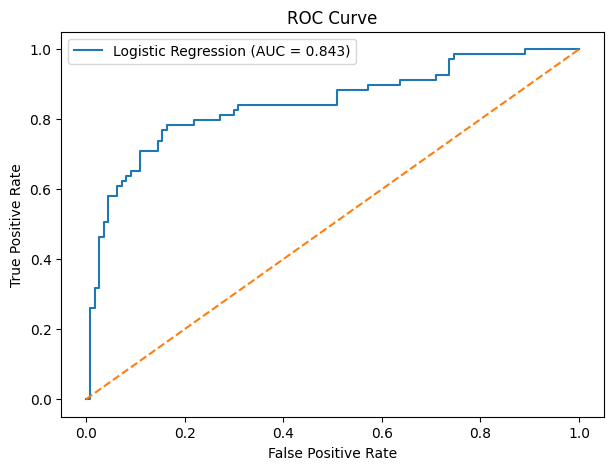

ROC-AUC score: 0.8433


In [32]:
#ROC Curve
fpr, tpr , thresholds = roc_curve(
    y_test,
    y_probability
)

auc = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC score:", round(auc, 4))   # ADDED -- scope lists ROC-AUC score as its own bullet, state it explicitly

## Part 10 — Model Interpretation (Explain Your Results)
*Scope requirements: explain the confusion matrix | explain the ROC curve | explain what the accuracy means*

**ADDED — this is written interpretation, not code. The scope notebook stopped at the coefficients plot; the actual test wants you to WRITE this in a markdown cell. Fill in your own numbers once you've run the cells above, using this as a template:**

> **Confusion matrix:** Of the passengers in the test set, the model correctly identified `TN` who did not survive and `TP` who did survive. It wrongly predicted `FP` non-survivors as survivors (false positives), and missed `FN` actual survivors, predicting they wouldn't survive (false negatives).
>
> **ROC curve:** The curve plots the True Positive Rate against the False Positive Rate at every possible decision threshold. A curve that bows toward the top-left corner means the model separates the two classes well. Our AUC of `___` means that, given one random survivor and one random non-survivor, the model ranks the survivor higher `___%` of the time (0.5 = random guessing, 1.0 = perfect separation).
>
> **Accuracy:** An accuracy of `___%` means the model correctly classified that percentage of passengers in the unseen test set. Because survival classes are imbalanced (more passengers died than survived), accuracy alone can overstate performance — the precision/recall/F1 numbers per class (Part 9) give the fuller picture.

In [33]:
# Examine Logistic Regression Feature Importance -- helps you talk about WHICH features drove the prediction,
# useful supporting evidence for your Part 10 written interpretation
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = abs(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute_Coefficient
5,Sex_male,-1.269598,1.269598
0,Pclass,-0.928698,0.928698
1,Age,-0.502878,0.502878
2,SibSp,-0.262672,0.262672
7,Embarked_S,-0.171784,0.171784
4,Fare,0.099599,0.099599
6,Embarked_Q,0.080683,0.080683
3,Parch,-0.067158,0.067158


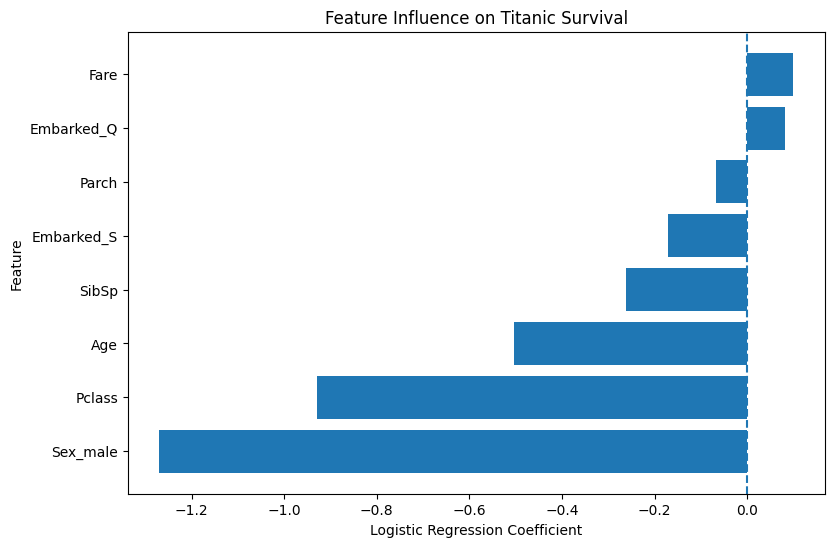

In [34]:
#Visualise Coefficients
coefficients_sorted = coefficients.sort_values(
    "Coefficient"
)

plt.figure(figsize=(9,6))

plt.barh(
    coefficients_sorted["Feature"],
    coefficients_sorted["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Influence on Titanic Survival")

plt.show()

## Bonus Question — Decision Tree, Random Forest, Model Comparison (optional, extra marks)
*Not in the original scope notebook — written in the same plain style as the rest of this notebook.*

In [35]:
# ADDED -- Bonus: Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_scaled, y_train)

dt_pred = decision_tree.predict(X_test_scaled)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))

Decision Tree Accuracy: 0.8212


In [36]:
# ADDED -- Bonus: Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_scaled, y_train)

rf_pred = random_forest.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.8156


In [37]:
# ADDED -- Bonus: Compare all three models
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, dt_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.821229
2,Random Forest,0.815642
